# OGC API - EDR endpoint in Examind - Example - Python client

By Quentin BIALOTA (Geomatys)

Contact : quentin.bialota@geomatys.com

---

### **/!\ WARNING**
This initial implementation of OGC API - Environmental Data Retrieval (EDR) may contain bugs. Please let me know if you find any.

In this tutorial we will query the Examind EDR endpoint with the [OWSLib](https://owslib.readthedocs.io/) python client,
and display the results as tables, maps and plots.

---

**Prerequisites :**
- Have an examind (via docker) running on your machine
- Have imported a GeoTIFF in Examind (through the web ui http://localhost:8080/examind [login: admin / password: admin]).
  This tutorial uses an RGB image (bands `Red`, `Green`, `Blue`) over Martinique. Any raster works, but you will have to adapt the coordinates below.
- In examind, have created an EDR service (in Web Services page) named `test-edr`, and added your data to it.
  The EDR collection id is the Examind data id (here `1`).

**Python dependencies :**
```
pip install owslib folium matplotlib pandas numpy requests
```

**Supported queries :** `position`, `radius`, `area`, `cube`, `trajectory`, `corridor` (and the same under `/instances/{instanceId}`).
The only output format is CoverageJSON (`application/prs.coverage+json`).

The server can limit the number of cells returned by a query with the `-Dexamind.edr.max.cells=<n>` JVM option : above this limit it answers `413`.

In [1]:
# Imports (Execute this cell once)
import json
import math

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from owslib.ogcapi.edr import EnvironmentalDataRetrieval

# Set the server ip here (before the /examind), by default: localhost:8080
SERVER_IP = "http://localhost:8080"
EDR_SERVICE_ID = "test-edr"
COLLECTION_ID = "1"

EDR_URL = f"{SERVER_IP}/examind/WS/edr/{EDR_SERVICE_ID}/"
edr = EnvironmentalDataRetrieval(EDR_URL)

### Helpers

EDR responses are [CoverageJSON](https://covjson.org/) documents. Examind returns two kinds of domains :
- **`Grid`** (`area`, `cube`, `radius`, `position` on a single point) : the `domain` gives the `x` and `y` axes (`start`, `stop`, `num`),
  and each entry of `ranges` gives the values of one parameter (here one band) as a flat list, in `y,x` order.
- **`MultiPoint`** (`position` on a `MULTIPOINT`, `trajectory`, and each line of a `corridor`) : a single `composite` axis
  holds the list of `[x, y]` positions, and each range holds one value per position.

The helpers below convert a coverage into numpy arrays or a pandas table, and display it on a map.
Cells without data (outside the requested geometry, or outside the collection) are `null` in CoverageJSON, `NaN` here.

> **Note :** the current Examind output has its grid `shape` array in `x,y` order while `axisNames` is `["y","x"]`
> (the values themselves are in `y,x` order). To stay independent of this, the helper reshapes the values
> with the `num` of each domain axis, in the `axisNames` order.

In [2]:
def axis_coords(axis):
    """Cell center coordinates of a regular CoverageJSON axis."""
    if "values" in axis:
        return np.array(axis["values"])
    return np.linspace(axis["start"], axis["stop"], axis["num"])


def range_values(rng):
    return np.array([np.nan if v is None else v for v in rng["values"]], dtype=float)


def coverage_to_arrays(cov):
    """Return (xs, ys, {parameter: 2D array [y, x]}) for a CoverageJSON grid."""
    axes = cov["domain"]["axes"]
    arrays = {}
    for name, rng in cov["ranges"].items():
        shape = [len(axis_coords(axes[a])) for a in rng["axisNames"]]
        arrays[name] = range_values(rng).reshape(shape)
    return axis_coords(axes["x"]), axis_coords(axes["y"]), arrays


def coverage_to_points(cov):
    """Return a DataFrame (lon, lat, one column per parameter) for a CoverageJSON MultiPoint."""
    positions = np.array(cov["domain"]["axes"]["composite"]["values"])
    df = pd.DataFrame({"lon": positions[:, 0], "lat": positions[:, 1]})
    for name, rng in cov["ranges"].items():
        df[name] = range_values(rng)
    return df


def grid_bounds(xs, ys):
    """Outer bounds [[south, west], [north, east]] of a grid given its cell centers."""
    dx = abs(xs[1] - xs[0]) if len(xs) > 1 else 0
    dy = abs(ys[1] - ys[0]) if len(ys) > 1 else 0
    return [[ys.min() - dy / 2, xs.min() - dx / 2], [ys.max() + dy / 2, xs.max() + dx / 2]]


def to_rgba(arrays, bands=("Red", "Green", "Blue")):
    """Stack 3 bands into an RGBA uint8 image (row 0 = first y value). Cells without data are transparent."""
    rgb = np.dstack([arrays[b] for b in bands])
    alpha = np.where(np.isnan(rgb).any(axis=2), 0, 255)
    return np.dstack([np.clip(np.nan_to_num(rgb), 0, 255), alpha]).astype(np.uint8)


def rgb_hex(row):
    return "#{:02x}{:02x}{:02x}".format(int(row.Red), int(row.Green), int(row.Blue))


def coverage_map(cov, zoom=12, opacity=0.8):
    """Folium map with a grid coverage drawn as an RGB image overlay."""
    xs, ys, arrays = coverage_to_arrays(cov)
    img = to_rgba(arrays)
    if ys[0] < ys[-1]:  # the image overlay expects the first row to be the north
        img = img[::-1]
    bounds = grid_bounds(xs, ys)
    m = folium.Map(location=[ys.mean(), xs.mean()], zoom_start=zoom)
    folium.raster_layers.ImageOverlay(img, bounds=bounds, opacity=opacity, mercator_project=True).add_to(m)
    folium.Rectangle(bounds, color="black", weight=1, fill=False, tooltip="Returned grid").add_to(m)
    return m


def add_points(m, points, radius=4):
    """Draw a DataFrame from coverage_to_points as circles filled with their RGB value."""
    for _, p in points.dropna().iterrows():
        folium.CircleMarker([p.lat, p.lon], radius=radius, weight=0, fill=True, fill_color=rgb_hex(p), fill_opacity=1,
                            tooltip=f"R={p.Red:.0f} G={p.Green:.0f} B={p.Blue:.0f}").add_to(m)
    return m


def edr_query(query_type, collection_id=COLLECTION_ID, **params):
    """Direct HTTP EDR query, for parameters OWSLib does not forward (see below)."""
    params = {k.replace("_", "-"): v for k, v in params.items()}
    r = requests.get(f"{EDR_URL}collections/{collection_id}/{query_type}", params=params)
    if r.status_code != 200:
        raise RuntimeError(f"{r.status_code}: {r.json().get('errorMessage', r.text)}")
    return r.json()

**OWSLib limitations (version 0.36) :** `EnvironmentalDataRetrieval.query_data` forwards `coords`, `bbox`, `crs`, `resolution-x/y`,
`within` and `corridor-width`, but :
- it sends the parameter filter as `parameter_names` instead of `parameter-name` (the server ignores it),
- it does not forward `within-units` and `width-units`, which are **required** by `radius` and `corridor`,
- it has no method for the `/instances/{instanceId}` queries.

For these cases we use the small `edr_query` helper above (plain HTTP).

### 1 - Discover the service

The landing page links to the API definition, the conformance classes and the collections.

In [3]:
pd.DataFrame(edr.links)[["rel", "title", "href"]]

,rel,title,href
0,self,This document,http://localhost:8080/examind/WS/edr/test-edr/
1,service-desc,API definition,http://localhost:8080/examind/WS/edr/test-edr/api
2,https://www.opengis.net/def/rel/ogc/1.0/confor...,Conformance classes,http://localhost:8080/examind/WS/edr/test-edr/...
3,https://www.opengis.net/def/rel/ogc/1.0/data,Collections,http://localhost:8080/examind/WS/edr/test-edr/...


The conformance classes tell which parts of the standard the server implements.

In [4]:
pd.DataFrame({"conformance class": edr.conformance()["conformsTo"]})

,conformance class
0,http://www.opengis.net/spec/ogcapi-common-1/1....
1,http://www.opengis.net/spec/ogcapi-common-1/1....
2,http://www.opengis.net/spec/ogcapi-common-1/1....
3,http://www.opengis.net/spec/ogcapi-common-2/1....
4,http://www.opengis.net/spec/ogcapi-edr-1/1.1/c...
5,http://www.opengis.net/spec/ogcapi-edr-1/1.1/c...
6,http://www.opengis.net/spec/ogcapi-edr-1/1.1/c...
7,http://www.opengis.net/spec/ogcapi-edr-1/1.1/c...
8,http://www.opengis.net/spec/ogcapi-edr-1/1.1/c...


### 2 - List the collections

Each collection is an Examind data. `edr.data()` lists the collections that expose EDR data queries.
We list them with their parameters, query types and extent, and draw the extents on a map.

In [5]:
print("EDR collections :", edr.data())

collections = edr.collections()["collections"]
pd.DataFrame([{
    "id": c["id"],
    "title": c.get("title"),
    "parameters": ", ".join(c.get("parameter_names", {})),
    "queries": ", ".join(c.get("data_queries", {})),
    "formats": ", ".join(c.get("output_formats", [])),
    "crs": ", ".join(c.get("crs", [])),
    "bbox": [round(v, 4) for v in c["extent"]["spatial"]["bbox"][0]],
} for c in collections])

EDR collections : ['1']


,id,title,parameters,queries,formats,crs,bbox
0,1,1,"Red, Green, Blue","position, radius, area, cube, trajectory, corr...",CoverageJSON,http://www.opengis.net/def/crs/OGC/1.3/CRS84,"[-61.6167, 14.2593, -60.6908, 15.0292]"


In [6]:
m = folium.Map(location=[14.6, -61.0], zoom_start=9)
for c in collections:
    minx, miny, maxx, maxy = c["extent"]["spatial"]["bbox"][0]
    folium.Rectangle([[miny, minx], [maxy, maxx]], tooltip=f"Collection {c['id']}", fill=True, fill_opacity=0.1).add_to(m)
m

The collection document describes its parameters (`parameter_names`) and, for each query type, the accepted output formats,
CRS and distance units (`data_queries.<query>.link.variables`). A client can build its queries from these metadata alone.

In [7]:
collection = edr.collection(COLLECTION_ID)

pd.DataFrame([{
    "parameter": name,
    "description": p.get("description"),
    "observed property": p["observedProperty"].get("label", p["observedProperty"].get("id")),
    "unit": (p.get("unit") or {}).get("symbol"),
} for name, p in collection["parameter_names"].items()])

,parameter,description,observed property,unit
0,Red,Red,Red,None
1,Green,Green,Green,None
2,Blue,Blue,Blue,None


In [8]:
pd.DataFrame([{
    "query": name,
    "href": q["link"]["href"],
    "formats": ", ".join(q["link"]["variables"].get("output_formats", [])),
    "crs": ", ".join(c["crs"] for c in q["link"]["variables"].get("crs_details", [])),
    "units": ", ".join(q["link"]["variables"].get("within_units", q["link"]["variables"].get("width_units", []))),
} for name, q in collection["data_queries"].items()])

,query,href,formats,crs,units
0,position,http://localhost:8080/examind/WS/edr/test-edr/...,CoverageJSON,CRS84,
1,radius,http://localhost:8080/examind/WS/edr/test-edr/...,CoverageJSON,CRS84,"m, km, mi, ft"
2,area,http://localhost:8080/examind/WS/edr/test-edr/...,CoverageJSON,CRS84,
3,cube,http://localhost:8080/examind/WS/edr/test-edr/...,CoverageJSON,CRS84,
4,trajectory,http://localhost:8080/examind/WS/edr/test-edr/...,CoverageJSON,CRS84,
5,corridor,http://localhost:8080/examind/WS/edr/test-edr/...,CoverageJSON,CRS84,"m, km, mi, ft"


### 3 - Instances

A collection can also expose **instances** (versions of the same data, for example successive model runs).
In Examind each collection currently has a single instance, which has its own metadata document and its own query links.

In [9]:
instances = requests.get(f"{EDR_URL}collections/{COLLECTION_ID}/instances").json()["instances"]
instance = instances[0]

print("Instances :", [i["id"] for i in instances])
pd.DataFrame(instance["links"])[["rel", "href"]]

Instances : ['1']


,rel,href
0,self,http://localhost:8080/examind/WS/edr/test-edr/...
1,collection,http://localhost:8080/examind/WS/edr/test-edr/...


### 4 - Position query : value at a point

`position` returns the value of each parameter at a point given in WKT (`POINT(lon lat)`, CRS84 by default).

In [10]:
cov = edr.query_data(COLLECTION_ID, "position", coords="POINT(-61.0 14.6)")

print("Parameters :", list(cov["parameters"]))
pd.DataFrame({name: rng["values"] for name, rng in cov["ranges"].items()}, index=["POINT(-61.0 14.6)"])

Parameters : ['Red', 'Green', 'Blue']


,Red,Green,Blue
POINT(-61.0 14.6),26.0,76.0,64.0


Several places can be queried at once with a `MULTIPOINT`. The response is a `MultiPoint` coverage with one value per point.
A point outside the collection extent gets `null` values : here we add a point in the sea, east of the image.

The marker color is the RGB value returned by the server.

In [11]:
places = {
    "Fort-de-France": (-61.07, 14.61),
    "Montagne Pelee": (-61.165, 14.81),
    "Le Lamentin": (-61.00, 14.61),
    "Sainte-Anne": (-60.88, 14.44),
    "Le Robert": (-60.94, 14.68),
    "Atlantic Ocean": (-60.50, 14.70),
}

multipoint = "MULTIPOINT(" + ",".join(f"({lon} {lat})" for lon, lat in places.values()) + ")"
cov = edr.query_data(COLLECTION_ID, "position", coords=multipoint)

print("Domain type :", cov["domain"]["domainType"])
points = coverage_to_points(cov)
points.index = list(places)
points

Domain type : MultiPoint


,lon,lat,Red,Green,Blue
Fort-de-France,-61.070,14.61,77.0,109.0,120.0
Montagne Pelee,-61.165,14.81,88.0,128.0,153.0
Le Lamentin,-61.000,14.61,75.0,93.0,117.0
Sainte-Anne,-60.880,14.44,108.0,155.0,181.0
Le Robert,-60.940,14.68,178.0,195.0,203.0
Atlantic Ocean,-60.500,14.70,NaN,NaN,NaN


In [12]:
m = folium.Map(location=[14.65, -61.0], zoom_start=10)
for name, p in points.iterrows():
    if p.isna().any():
        folium.Marker([p.lat, p.lon], tooltip=f"{name} : no data").add_to(m)
        continue
    folium.CircleMarker([p.lat, p.lon], radius=12, color="black", weight=1, fill=True, fill_color=rgb_hex(p), fill_opacity=1,
                        tooltip=f"{name} : R={p.Red:.0f} G={p.Green:.0f} B={p.Blue:.0f}").add_to(m)
m

**Selecting parameters :** use `parameter-name` (a comma separated list). An unknown name returns `400`.

In [13]:
cov = edr_query("position", coords="POINT(-61.0 14.6)", parameter_name="Red,Blue")
print("Parameters returned :", list(cov["ranges"]))

Parameters returned : ['Red', 'Blue']


### 5 - Coordinate reference systems

`coords` (and `bbox`) are read in the CRS given by `crs`, in the **axis order of that CRS** :
- `CRS84` (default) : longitude, latitude,
- `EPSG:4326` : latitude, longitude,
- `EPSG:3857` : easting, northing, in meters.

The three queries below target the same place and return the same values.

In [14]:
# Web Mercator (EPSG:3857) coordinates of the point
x = 6378137 * math.radians(-61.0)
y = 6378137 * math.log(math.tan(math.pi / 4 + math.radians(14.6) / 2))

queries = {
    "CRS84 (default)": dict(coords="POINT(-61.0 14.6)"),
    "EPSG:4326": dict(coords="POINT(14.6 -61.0)", crs="EPSG:4326"),
    "EPSG:3857": dict(coords=f"POINT({x:.0f} {y:.0f})", crs="EPSG:3857"),
}

rows = []
for label, params in queries.items():
    cov = edr_query("position", **params)
    rows.append({"crs": label, "coords": params["coords"], **{b: r["values"][0] for b, r in cov["ranges"].items()}})
pd.DataFrame(rows).set_index("crs")

,coords,Red,Green,Blue
crs,,,,
CRS84 (default),POINT(-61.0 14.6),26.0,76.0,64.0
EPSG:4326,POINT(14.6 -61.0),26.0,76.0,64.0
EPSG:3857,POINT(-6790489 1643144),26.0,76.0,64.0


With `EPSG:4326`, a point written in longitude, latitude order falls far outside the data :

In [15]:
r = requests.get(f"{EDR_URL}collections/{COLLECTION_ID}/position", params={"coords": "POINT(-61.0 14.6)", "crs": "EPSG:4326"})
print(r.status_code, r.json()["errorMessage"])

400 The requested 'coords' does not intersect the extent of collection '1'.


### 6 - Area query : data inside a polygon

`area` returns the grid covering a `POLYGON`. Cells outside the polygon are `null`.
We display it on a map and band by band. Here we build a hexagon around Le Lamentin to see the masking.

POLYGON((-60.97349 14.62000,-60.99675 14.65897,-61.04325 14.65897,-61.06651 14.62000,-61.04325 14.58103,-60.99675 14.58103,-60.97349 14.62000))
Grid : 66 x 55 cells, 1036 without data



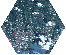

In [16]:
# Regular hexagon of 5 km radius (the longitude is scaled so that it looks regular on the map)
center_lon, center_lat, radius_deg = -61.02, 14.62, 0.045
hexagon = [(center_lon + radius_deg * math.cos(math.radians(a)) / math.cos(math.radians(center_lat)),
            center_lat + radius_deg * math.sin(math.radians(a))) for a in range(0, 360, 60)]
hexagon.append(hexagon[0])  # a WKT polygon ring must be closed
polygon = "POLYGON((" + ",".join(f"{x:.5f} {y:.5f}" for x, y in hexagon) + "))"
print(polygon)

cov = edr.query_data(COLLECTION_ID, "area", coords=polygon)

xs, ys, arrays = coverage_to_arrays(cov)
print(f"Grid : {len(xs)} x {len(ys)} cells, {np.isnan(arrays['Red']).sum()} without data")

m = coverage_map(cov)
folium.Polygon([(y, x) for x, y in hexagon], color="red", fill=False, tooltip="Requested polygon").add_to(m)
m

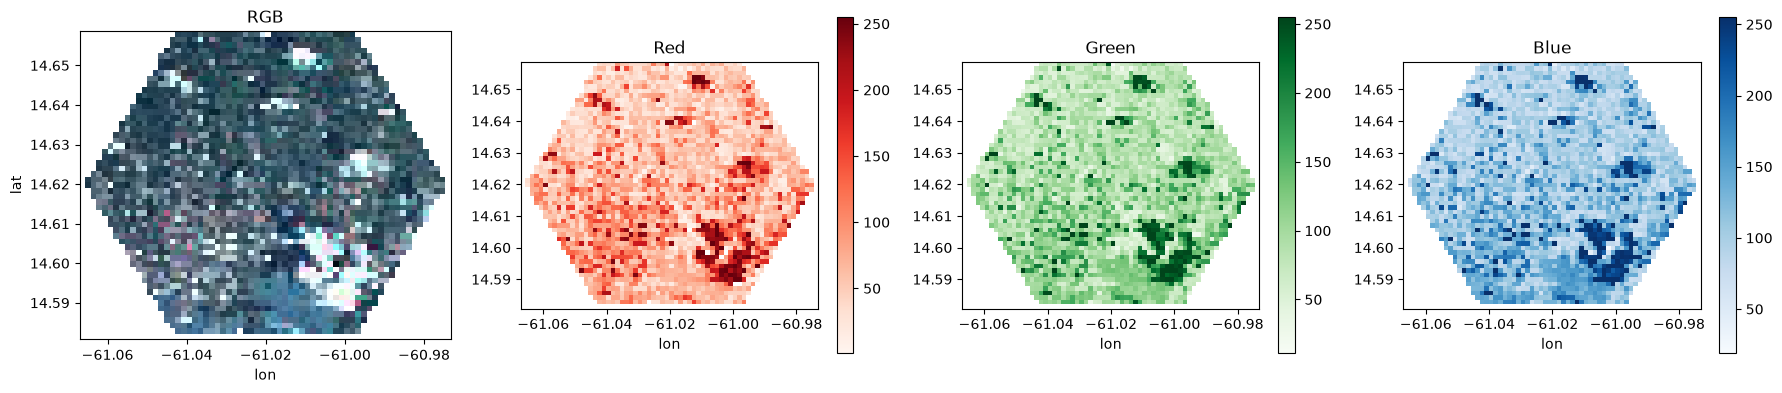

In [17]:
extent = [xs.min(), xs.max(), ys.min(), ys.max()]
origin = "upper" if ys[0] > ys[-1] else "lower"
fig, axs = plt.subplots(1, 4, figsize=(18, 4.5))
axs[0].imshow(to_rgba(arrays), extent=extent, origin=origin)
axs[0].set_title("RGB")
for ax, (band, cmap) in zip(axs[1:], [("Red", "Reds"), ("Green", "Greens"), ("Blue", "Blues")]):
    im = ax.imshow(arrays[band], extent=extent, cmap=cmap, origin=origin)
    ax.set_title(band)
    fig.colorbar(im, ax=ax, shrink=0.8)
for ax in axs:
    ax.set_xlabel("lon")
axs[0].set_ylabel("lat")
plt.tight_layout()
plt.show()

Statistics per band (the `null` cells are not counted) :

In [18]:
pd.DataFrame({band: a.ravel() for band, a in arrays.items()}).describe().round(1)

,Red,Green,Blue
count,2594.0,2604.0,2604.0
mean,80.9,107.5,122.6
std,53.6,50.7,48.9
min,1.0,11.0,19.0
25%,44.0,73.0,88.0
50%,67.0,94.0,109.0
75%,99.0,125.0,144.0
max,255.0,255.0,255.0


**Resampling :** `resolution-x` and `resolution-y` give the number of cells wanted along each axis.
Here we ask for a 4 x 3 grid over a square and show it as a table (rows = latitude, columns = longitude).

In [19]:
square = "POLYGON((-61.1 14.6,-61.0 14.6,-61.0 14.7,-61.1 14.7,-61.1 14.6))"
cov = edr.query_data(COLLECTION_ID, "area", coords=square, resolution_x=4, resolution_y=3)
xs, ys, arrays = coverage_to_arrays(cov)

pd.DataFrame(arrays["Red"], index=pd.Index(ys.round(4), name="lat \\ lon"), columns=xs.round(4))

,-61.0875,-61.0625,-61.0375,-61.0125
lat \ lon,,,,
14.6833,42.132652,42.017319,53.060978,96.290771
14.6500,27.394169,40.093235,31.686420,37.658512
14.6167,21.679560,71.022758,106.014496,66.063667


### 7 - Cube query : data inside a bounding box

`cube` takes a `bbox` (`minx,miny,maxx,maxy`). Here we request the whole island, resampled to 200 x 200 cells
to keep the response small (without resampling, the full image is 641 x 533 cells, about 5 MB of JSON).


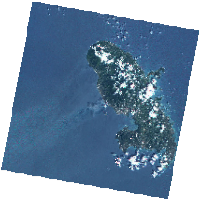

In [20]:
bbox = collection["extent"]["spatial"]["bbox"][0]
cov = edr.query_data(COLLECTION_ID, "cube", bbox=bbox, resolution_x=200, resolution_y=200)
coverage_map(cov, zoom=10, opacity=0.9)

### 8 - Radius query : data around a point

`radius` takes a `POINT`, a distance `within` and its unit `within-units` (required : `m`, `km`, `mi` or `ft`, as listed in the collection metadata).

The server returns the grid enclosing the circle, with `null` for the cells outside the circle.

In [21]:
lon, lat, radius_km = -61.0, 14.6, 1
cov = edr_query("radius", coords=f"POINT({lon} {lat})", within=radius_km, within_units="km")
xs, ys, arrays = coverage_to_arrays(cov)
print(f"Grid : {len(xs)} x {len(ys)} cells, {(~np.isnan(arrays['Red'])).sum()} inside the circle")

m = coverage_map(cov, zoom=14)
folium.Circle([lat, lon], radius=radius_km * 1000, color="red", fill=False, tooltip=f"{radius_km} km").add_to(m)
m

Grid : 14 x 14 cells, 119 inside the circle


Mean value per band inside the circle, for several radius and units :

In [22]:
rows = []
for within, units in [(500, "m"), (1, "km"), (1, "mi"), (2, "km")]:
    cov = edr_query("radius", coords=f"POINT({lon} {lat})", within=within, within_units=units, parameter_name="Red,Green,Blue")
    _, _, arrays = coverage_to_arrays(cov)
    rows.append({"radius": f"{within} {units}", "cells": int((~np.isnan(arrays["Red"])).sum()),
                 **{b: np.nanmean(a) for b, a in arrays.items()}})
pd.DataFrame(rows).set_index("radius").round(1)

,cells,Red,Green,Blue
radius,,,,
500 m,31,139.4,161.4,174.5
1 km,119,160.9,175.9,186.3
1 mi,321,123.1,144.8,158.9
2 km,490,105.2,129.8,145.8


### 9 - Trajectory query : data along a line

`trajectory` takes a `LINESTRING`. The response is a `MultiPoint` coverage : the line is sampled at the grid resolution,
and each point carries its position and its values. We draw the points on the map, then plot the bands against the distance.

In [23]:
line = [(-61.1, 14.6), (-61.05, 14.68), (-60.98, 14.7)]
wkt = "LINESTRING(" + ",".join(f"{x} {y}" for x, y in line) + ")"
cov = edr.query_data(COLLECTION_ID, "trajectory", coords=wkt)

track = coverage_to_points(cov)
print("Domain type :", cov["domain"]["domainType"], "-", len(track), "points")

m = folium.Map(location=[track.lat.mean(), track.lon.mean()], zoom_start=12)
folium.PolyLine([(y, x) for x, y in line], color="red", weight=2, tooltip="Requested line").add_to(m)
add_points(m, track)

Domain type : MultiPoint - 133 points


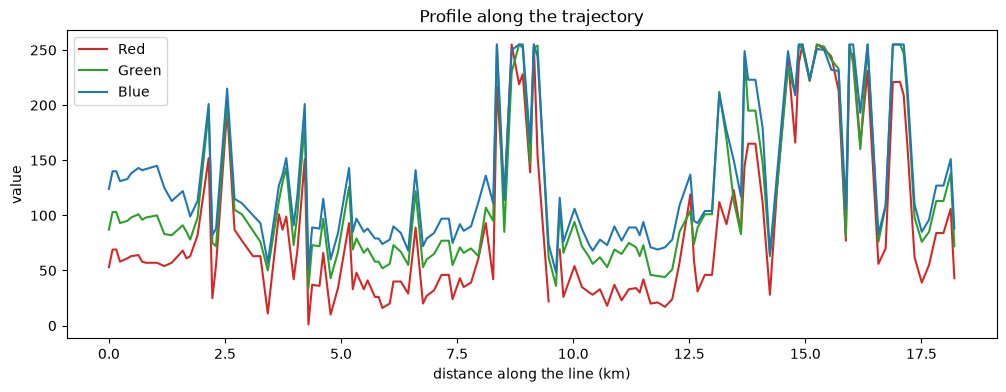

In [24]:
# Cumulative distance along the line (km), equirectangular approximation
dx = np.radians(track.lon.diff().fillna(0)) * np.cos(np.radians(track.lat))
dy = np.radians(track.lat.diff().fillna(0))
track["distance_km"] = 6371 * np.hypot(dx, dy).cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
for band, color in [("Red", "tab:red"), ("Green", "tab:green"), ("Blue", "tab:blue")]:
    ax.plot(track.distance_km, track[band], color=color, label=band)
ax.set_xlabel("distance along the line (km)")
ax.set_ylabel("value")
ax.legend()
ax.set_title("Profile along the trajectory")
plt.show()

*A `LINESTRINGM` (with a time per vertex) is refused with `400` on this collection, since it has no temporal axis.
The number of points is fixed by the grid resolution : `resolution-x` is not accepted on `trajectory`.*

### 10 - Corridor query : data along a line, with a width

`corridor` takes a `LINESTRING`, a `corridor-width` and its unit `width-units` (required).
The response is a `CoverageCollection` : one `MultiPoint` coverage per line parallel to the axis, from one edge of the corridor to the other.
- `resolution-x` : number of lines across the corridor,
- `resolution-y` : number of points along each line.

Without them, the server samples at the grid resolution.

In [25]:
cov = edr_query("corridor", coords=wkt, corridor_width=500, width_units="m", resolution_x=5, resolution_y=60)

lines = [coverage_to_points(c) for c in cov["coverages"]]
print("Type :", cov["type"], "-", len(lines), "lines of", [len(l) for l in lines], "points")

m = folium.Map(location=[track.lat.mean(), track.lon.mean()], zoom_start=12)
folium.PolyLine([(y, x) for x, y in line], color="red", weight=2, tooltip="Corridor axis").add_to(m)
for l in lines:
    add_points(m, l, radius=3)
m

Type : CoverageCollection - 5 lines of [60, 60, 60, 60, 60] points


The Red band as a (distance across the corridor × position along the line) image :

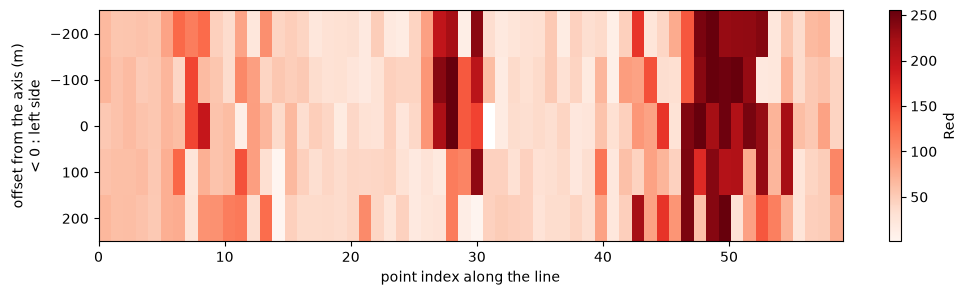

In [26]:
section = np.array([l.Red.to_numpy() for l in lines])
offsets = np.linspace(-250, 250, len(lines))

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(section, aspect="auto", cmap="Reds", extent=[0, section.shape[1] - 1, offsets[-1], offsets[0]])
ax.set_xlabel("point index along the line")
ax.set_ylabel("offset from the axis (m)\n< 0 : left side")
fig.colorbar(im, ax=ax, label="Red")
plt.show()

### 11 - Query an instance

The same queries are available under `/collections/{collectionId}/instances/{instanceId}/`.
The instance document gives their URL in its `data_queries` links.

In [27]:
href = instance["data_queries"]["position"]["link"]["href"]
print(href)

cov = requests.get(href, params={"coords": "POINT(-61.0 14.6)"}).json()
pd.DataFrame({name: rng["values"] for name, rng in cov["ranges"].items()}, index=[f"instance {instance['id']}"])

http://localhost:8080/examind/WS/edr/test-edr/collections/1/instances/1/position


,Red,Green,Blue
instance 1,26.0,76.0,64.0


### 12 - Errors

Invalid queries return an HTTP error code and a JSON body with an `errorMessage`. Here are some examples.

In [28]:
point = "coords=POINT(-61.0 14.6)"
linestring = "coords=LINESTRING(-61.1 14.6,-61.0 14.7)"
cases = [
    ("missing coords", "position", "", {}),
    ("invalid WKT", "position", "coords=NOT_WKT", {}),
    ("wrong geometry type", "position", linestring, {}),
    ("outside the collection", "position", "coords=POINT(0 0)", {}),
    ("lon/lat order with EPSG:4326", "position", point + "&crs=EPSG:4326", {}),
    ("unknown CRS", "position", point + "&crs=EPSG:99999", {}),
    ("unsupported z", "position", point + "&z=10", {}),
    ("no time axis", "position", point + "&datetime=2020-01-01T00:00:00Z", {}),
    ("unknown parameter-name", "position", point + "&parameter-name=unknown", {}),
    ("unsupported format (f)", "position", point + "&f=csv", {}),
    ("unsupported format (Accept)", "position", point, {"Accept": "application/xml"}),
    ("missing within", "radius", point, {}),
    ("missing within-units", "radius", point + "&within=1", {}),
    ("invalid unit", "radius", point + "&within=1&within-units=kg", {}),
    ("resolution-y missing", "area", "coords=" + square + "&resolution-x=4", {}),
    ("bbox with 3 values", "cube", "bbox=-61.1,14.6,-61.0", {}),
    ("inverted bbox (minx > maxx)", "cube", "bbox=-61.0,14.7,-61.1,14.6", {}),
    ("parameter not accepted by the query", "trajectory", linestring + "&resolution-x=5", {}),
    ("unknown parameter", "position", point + "&foo=1", {}),
    ("time on a trajectory", "trajectory", "coords=LINESTRINGM(-61.1 14.6 0,-61.0 14.7 10)", {}),
    ("missing corridor-width", "corridor", linestring, {}),
    ("missing width-units", "corridor", linestring + "&corridor-width=500", {}),
    ("unknown instance", "instances/foo/position", point, {}),
]

rows = []
for label, query, params, headers in cases:
    r = requests.get(f"{EDR_URL}collections/{COLLECTION_ID}/{query}?{params}", headers=headers)
    rows.append({"case": label, "query": query, "status": r.status_code, "message": r.json().get("errorMessage")})
r = requests.get(f"{EDR_URL}collections/unknown/position?{point}")
rows.append({"case": "unknown collection", "query": "position", "status": r.status_code, "message": r.json().get("errorMessage")})

pd.set_option("display.max_colwidth", None)
pd.DataFrame(rows)

,case,query,status,message
0,missing coords,position,400,Missing required parameter 'coords'. Example: ?coords=POINT(2.35 48.85)
1,invalid WKT,position,400,Expected word but found '_' (line 1)
2,wrong geometry type,position,400,"Unsupported geometry type LineString for this query, expected POINT or MULTIPOINT"
3,outside the collection,position,400,The requested 'coords' does not intersect the extent of collection '1'.
4,lon/lat order with EPSG:4326,position,400,The requested 'coords' does not intersect the extent of collection '1'.
5,unknown CRS,position,400,Invalid 'crs' parameter : EPSG:99999
6,unsupported z,position,400,The 'z' parameter is not supported by this service yet.
7,no time axis,position,400,The 'datetime' parameter is not supported: this collection has no temporal axis.
8,unknown parameter-name,position,400,Unknown 'parameter-name' value: unknown
9,unsupported format (f),position,400,Invalid 'f' parameter: Unknown output format: csv. Expected CoverageJSON or GeoJSON.
